<a href="https://colab.research.google.com/github/VadimFilips/ProjectFilipsGit/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5%20%E2%84%964/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%E2%84%964.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
#Классификатор CatBoost.
!pip install catboost

Распределение выживаемости:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


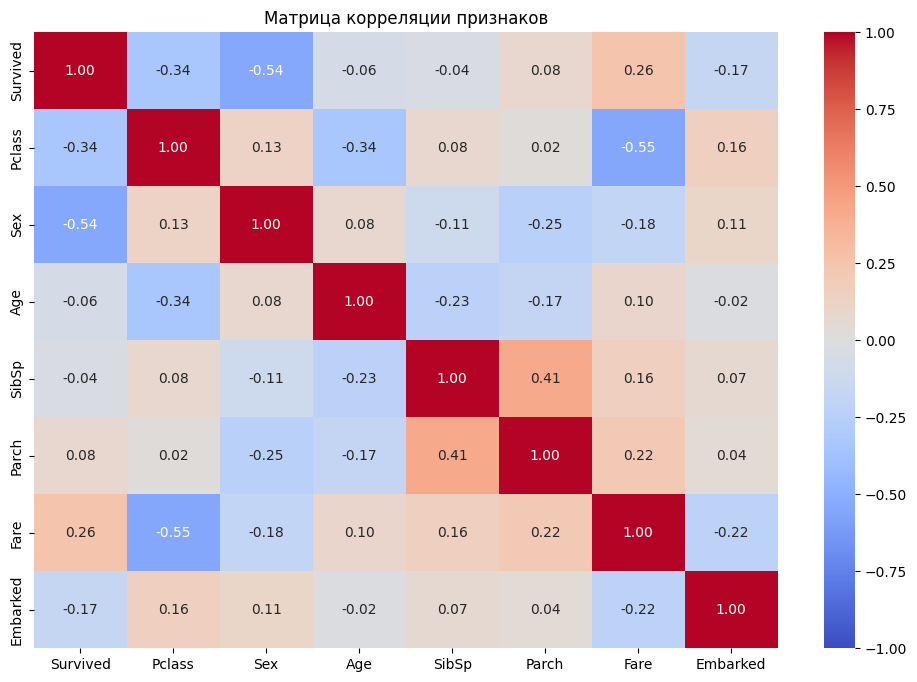

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[79]	valid_0's binary_logloss: 0.415442
Сравнение классификаторов:

Gradient Boosting:
Точность: 0.8380
Отчет классификации:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       105
           1       0.83      0.77      0.80        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179


CatBoost:
Точность: 0.8324
Отчет классификации:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       105
           1       0.82      0.76      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179


Extra Trees:
Точность: 0.8156
Отчет классификации:
              precision 

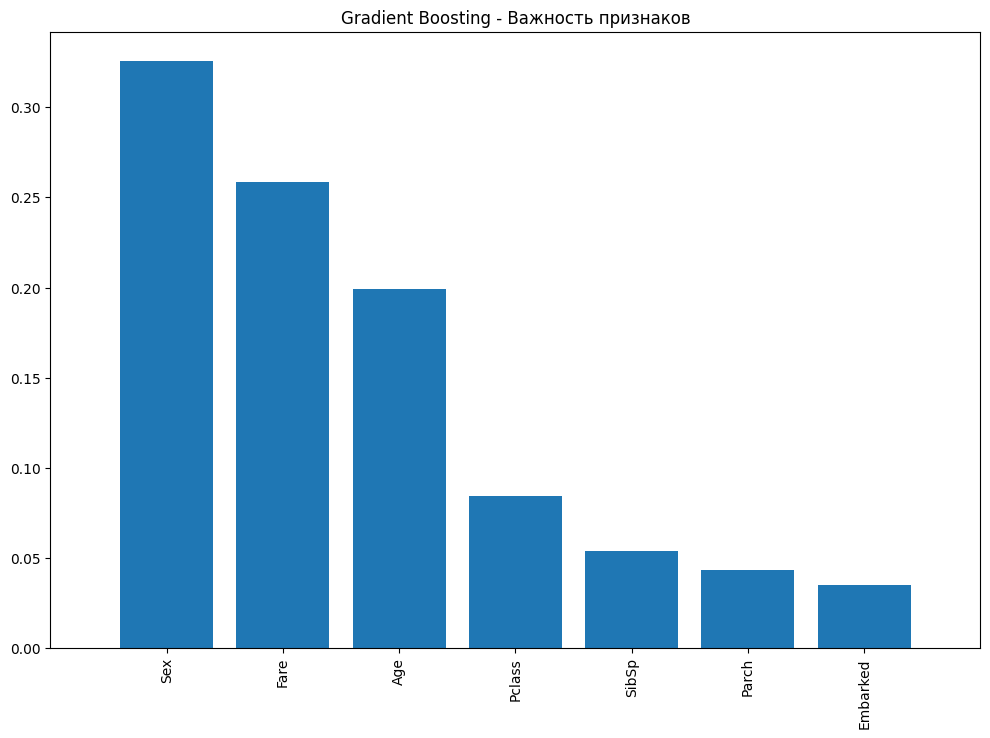

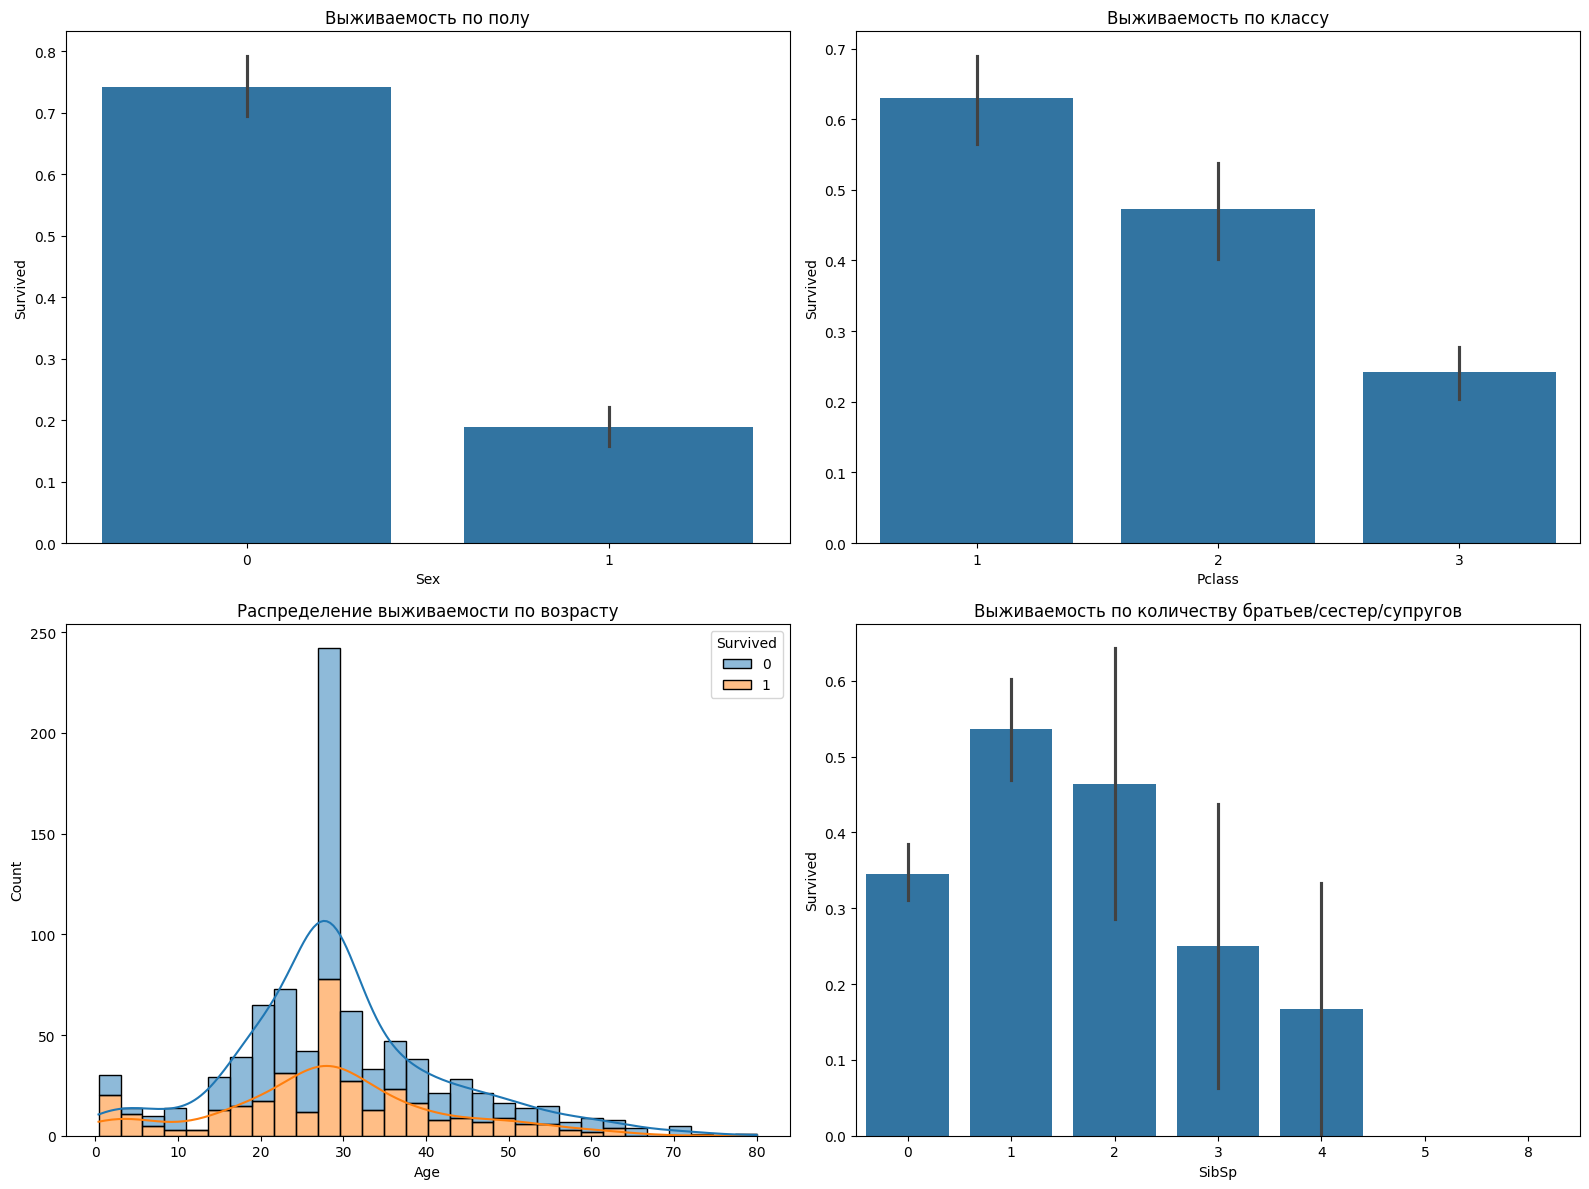

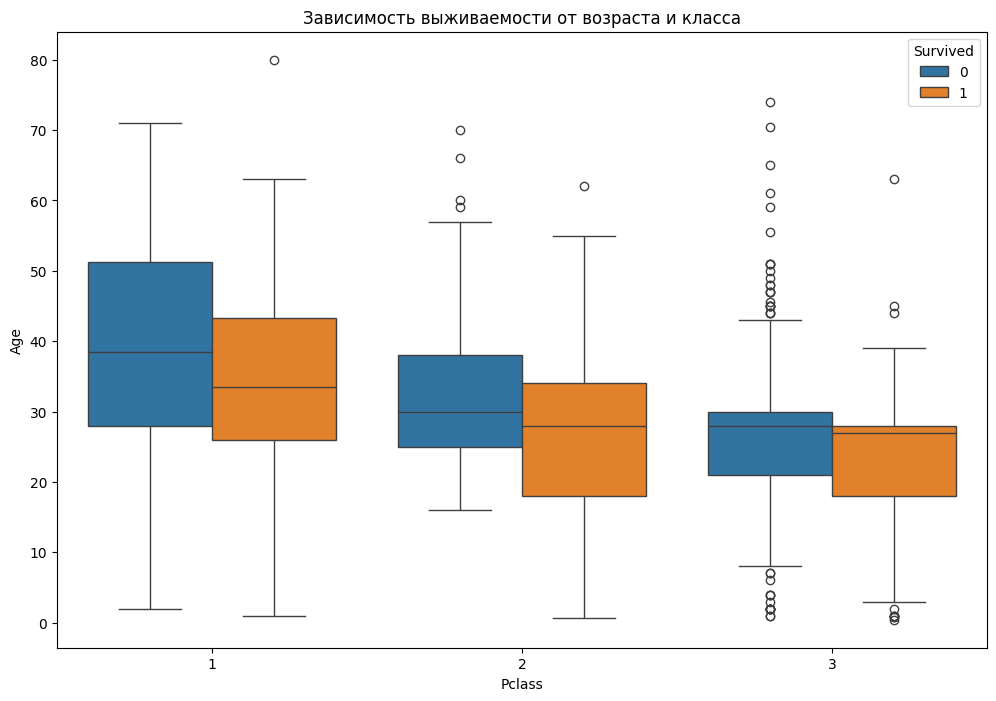

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
import catboost as cb
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

# Загрузка данных
data = pd.read_csv('Titanic-Dataset.csv')

# Обработка пропусков
# Заполняем пропущенные значения
data.fillna({'Age': data['Age'].median(),
             'Embarked': data['Embarked'].mode()[0]},
            inplace=True)

# Удаляем столбцы, которые не будем использовать
data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Кодирование категориальных признаков
label_encoders = {}
for column in ['Sex', 'Embarked']:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# Анализ распределения целевого признака
print("Распределение выживаемости:")
print(data['Survived'].value_counts(normalize=True))

# Визуализация корреляции
plt.figure(figsize=(12, 8))
corr_matrix = data.corr()
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmin=-1,
            vmax=1)
plt.title('Матрица корреляции признаков')
plt.show()

# Разделение данных
X = data.drop('Survived', axis=1)
y = data['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Словарь для хранения результатов
results = {}


# Gradient Boosting Classifier
gbc = GradientBoostingClassifier(
    n_estimators=200,          # Количество деревьев
    max_depth=4,              # Максимальная глубина деревьев
    learning_rate=0.1,        # Скорость обучения
    min_samples_split=10,     # Минимальное количество объектов для разделения
    min_samples_leaf=5,       # Минимальное количество объектов в листе
    subsample=0.8,            # Доля объектов для каждого дерева
    max_features='sqrt',      # Максимальное количество признаков для каждого дерева
    random_state=42,
    verbose=0
)
gbc.fit(X_train, y_train)
y_pred_gbc = gbc.predict(X_test)
results['Gradient Boosting'] = {
    'accuracy': accuracy_score(y_test, y_pred_gbc),
    'report': classification_report(y_test, y_pred_gbc)
}
# CatBoost Classifier
cbc = cb.CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    eval_metric='Accuracy',
    random_seed=42,
    use_best_model=False,
    verbose=False
)

cbc.fit(X_train, y_train)
y_pred_cbc = cbc.predict(X_test)
results['CatBoost'] = {
    'accuracy': accuracy_score(y_test, y_pred_cbc),
    'report': classification_report(y_test, y_pred_cbc)
}

# Extra Trees Classifier

etc = ExtraTreesClassifier(
    n_estimators=200,          # Количество деревьев
    max_depth=None,           # Максимальная глубина (None = без ограничений)
    min_samples_split=2,      # Минимальное количество объектов для разделения
    min_samples_leaf=1,       # Минимальное количество объектов в листе
    max_features='sqrt',      # Допустимые значения: 'sqrt', 'log2', None или число
    criterion='gini',         # Функция качества разбиения
    bootstrap=False,         # Не использовать бутстреп
    oob_score=False,         # Не использовать out-of-bag оценку
    random_state=42,
    n_jobs=-1                # Использовать все ядра
)
etc.fit(X_train, y_train)
y_pred_etc = etc.predict(X_test)
results['Extra Trees'] = {
    'accuracy': accuracy_score(y_test, y_pred_etc),
    'report': classification_report(y_test, y_pred_etc)}

# Light Gradient Boosting Machine LightGBM
# Оптимизированный LightGBM Classifier для Titanic
lgbm = lgb.LGBMClassifier(
    boosting_type='gbdt',
    learning_rate=0.03,          # Оптимальный темп обучения
    n_estimators=300,           # Достаточное количество итераций
    num_leaves=31,              # Оптимальное количество листьев
    max_depth=7,                # Ограничение глубины деревьев
    min_child_samples=5,        # Минимум образцов в листе
    subsample=0.8,              # Доля выборки для каждого дерева
    colsample_by_tree=0.8,      # Доля признаков для каждого дерева
    reg_alpha=0.1,              # L1 регуляризация
    reg_lambda=0.1,             # L2 регуляризация
    objective='binary',         # Бинарная классификация
    verbose=-1,                 # Отключение вывода
    force_col_wise=True         # Оптимизация обработки данных
)

# Обучение модели с валидацией
evals_result = {}
lgbm.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],  # Добавляем валидационный набор
    eval_metric='binary_logloss', # Указываем метрику валидации
    callbacks=[lgb.early_stopping(20)]  # Ранняя остановка через колбэк
)


y_pred_lgbm = lgbm.predict(X_test)
results['LightGBM'] = {
    'accuracy': accuracy_score(y_test, y_pred_lgbm),
    'report': classification_report(y_test, y_pred_lgbm)
}

# SVM с линейным ядром
svm_optimized = SVC(
    kernel='linear',
    C=2,            # Оптимальное значение регуляризации
    tol=0.001,        # Допуск для сходимости
    max_iter=2000,    # Максимальное число итераций
    random_state=42,
    probability=True,  # Для получения вероятностей
    class_weight='balanced'
)

svm_optimized.fit(X_train, y_train)
y_pred_svm_opt = svm_optimized.predict(X_test)

results['SVM Linear Optimized'] = {
    'accuracy': accuracy_score(y_test, y_pred_svm_opt),
    'report': classification_report(y_test, y_pred_svm_opt)
}

# Вывод результатов
print("Сравнение классификаторов:")
for model, metrics in results.items():
    print(f"\n{model}:")
    print(f"Точность: {metrics['accuracy']:.4f}")
    print("Отчет классификации:")
    print(metrics['report'])

# Находим лучшую модель
best_model = max(results, key=lambda k: results[k]['accuracy'])
best_accuracy = results[best_model]['accuracy']

print(f"\nЛучшая модель: {best_model} с точностью {best_accuracy:.4f}")

# Дополнительно можно вывести детальную информацию о лучшей модели
print(f"\nДетальный отчет по лучшей модели ({best_model}):")
print(results[best_model]['report'])

#ВИЗУАЛИЗАЦИЯ
# Создадим функцию для визуализации
def plot_feature_importance(data, model, title):
    # Получаем важность признаков
    importances = model.feature_importances_
    feature_names = data.columns

    # Сортируем по важности
    indices = np.argsort(importances)[::-1]

    # Создаем график
    plt.figure(figsize=(12, 8))
    plt.title(f'{title} - Важность признаков')
    plt.bar(range(X.shape[1]), importances[indices], align='center')
    plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=90)
    plt.xlim([-1, X.shape[1]])
    plt.show()

# Визуализация важности признаков для лучшей модели
if best_model == 'LightGBM':
    plot_feature_importance(X, lgbm, 'LightGBM')
elif best_model == 'Gradient Boosting':
    plot_feature_importance(X, gbc, 'Gradient Boosting')
elif best_model == 'CatBoost':
    plot_feature_importance(X, cbc, 'CatBoost')
elif best_model == 'Extra Trees':
    plot_feature_importance(X, etc, 'Extra Trees')


# Визуализация распределения выживаемости по ключевым признакам
plt.figure(figsize=(16, 12))

# По полу
plt.subplot(2, 2, 1)
sns.barplot(x='Sex', y='Survived', data=data)
plt.title('Выживаемость по полу')

# По классу
plt.subplot(2, 2, 2)
sns.barplot(x='Pclass', y='Survived', data=data)
plt.title('Выживаемость по классу')

# По возрасту
plt.subplot(2, 2, 3)
sns.histplot(data, x='Age', hue='Survived', multiple='stack', kde=True)
plt.title('Распределение выживаемости по возрасту')

# По количеству родственников
plt.subplot(2, 2, 4)
sns.barplot(x='SibSp', y='Survived', data=data)
plt.title('Выживаемость по количеству братьев/сестер/супругов')

plt.tight_layout()
plt.show()

# График зависимости выживаемости от возраста и класса
plt.figure(figsize=(12, 8))
sns.boxplot(x='Pclass', y='Age', hue='Survived', data=data)
plt.title('Зависимость выживаемости от возраста и класса')
plt.show()

In [37]:
# ExtraTreesClassifier с использованием GridSearchCV для подбора гиперпараметров
#Внимание! Выполнение кода требует времени
# !Подбор гиперпарамеров для датасета занимает 7 минут
#  ExtraTreesClassifier
# Импорты необходимых библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Загрузка и предобработка данных
def load_and_preprocess_data():
    # Загрузка данных
    data = pd.read_csv('Titanic-Dataset.csv')

    # Обработка пропусков
    data.fillna({
        'Age': data['Age'].median(),
        'Embarked': data['Embarked'].mode()[0]
    }, inplace=True)

    # Кодирование категориальных признаков
    label_encoders = {}
    for column in ['Sex', 'Embarked']:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le

    # Подготовка данных
    X = data.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
    y = data['Survived']

    return train_test_split(X, y, test_size=0.2, random_state=42)

# Получение тренировочных и тестовых данных
X_train, X_test, y_train, y_test = load_and_preprocess_data()

# Определение сетки параметров для поиска
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Инициализация классификатора
clf = ExtraTreesClassifier(random_state=42)

# Настройка GridSearchCV
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Обучение модели
print("Запуск поиска оптимальных параметров...")
grid_search.fit(X_train, y_train)

# Вывод результатов
print("\nЛучшие найденные параметры:")
print(grid_search.best_params_)
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_:.4f}")

# Оценка на тестовой выборке
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test)

# Метрики качества
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\nРезультаты на тестовой выборке:")
print(f"Точность: {accuracy:.4f}")
print("Отчет классификации:")
print(report)

# Важность признаков
feature_importances = best_clf.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("\nВажность признаков:")
print(importance_df)

Запуск поиска оптимальных параметров...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Лучшие найденные параметры:
{'max_depth': 10, 'max_features': None, 'min_samples_split': 5, 'n_estimators': 200}
Лучшая точность на кросс-валидации: 0.8342

Результаты на тестовой выборке:
Точность: 0.8101
Отчет классификации:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       105
           1       0.82      0.69      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179


Важность признаков:
    Feature  Importance
1       Sex    0.462755
0    Pclass    0.168092
2       Age    0.117573
5      Fare    0.117287
3     SibSp    0.052986
6  Embarked    0.040887
4     Parch    0.040421


In [73]:
# SVM - линейное ядро с использованием GridSearchCV для подбора гиперпараметров
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.exceptions import ConvergenceWarning
import warnings

# Загрузка и предобработка данных
def load_and_preprocess_data():
    # Загрузка данных
    data = pd.read_csv('Titanic-Dataset.csv')

    # Обработка пропусков
    data.fillna({
        'Age': data['Age'].median(),
        'Embarked': data['Embarked'].mode()[0]
    }, inplace=True)

    # Кодирование категориальных признаков
    label_encoders = {}
    for column in ['Sex', 'Embarked']:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le

    # Подготовка данных
    X = data.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
    y = data['Survived']

    return train_test_split(X, y, test_size=0.2, random_state=42)

# Получение тренировочных и тестовых данных
X_train, X_test, y_train, y_test = load_and_preprocess_data()

# Подавляем предупреждения о сходимости
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Создаем пайплайн с масштабированием
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', random_state=42))
])

# Уточненная сетка параметров
param_grid = {
    'svm__C': [5, 10, 15],
    'svm__tol': [1e-5, 1e-4],
    'svm__max_iter': [2000, 3000],
    'svm__class_weight': [None, 'balanced']
}

# Настройка GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Обучение модели
grid_search.fit(X_train, y_train)

# Вывод лучших параметров
print("Лучшие параметры:", grid_search.best_params_)

# Оценка модели
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)

# Расчет метрик
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Вывод результатов
print(f"\nТочность модели: {accuracy:.4f}")
print("\nОтчет классификации:")
print(report)

# Сохранение результатов
results['SVM Linear Optimized'] = {
    'accuracy': accuracy,
    'report': report
}

# Дополнительно можно вывести матрицу ошибок
from sklearn.metrics import confusion_matrix
print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred))

# И ROC-AUC (если классы сбалансированы)
from sklearn.metrics import roc_auc_score
try:
    y_pred_proba = best_svm.decision_function(X_test)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\nROC AUC: {roc_auc:.4f}")
    results['SVM Linear Optimized']['roc_auc'] = roc_auc
except Exception as e:
    print(f"Ошибка при вычислении ROC AUC: {e}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Лучшие параметры: {'svm__C': 10, 'svm__class_weight': None, 'svm__max_iter': 2000, 'svm__tol': 1e-05}

Точность модели: 0.7374

Отчет классификации:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       105
           1       0.67      0.73      0.70        74

    accuracy                           0.74       179
   macro avg       0.73      0.74      0.73       179
weighted avg       0.74      0.74      0.74       179


Матрица ошибок:
[[78 27]
 [20 54]]

ROC AUC: 0.7940


In [76]:
#Градиентный бустинг с баласнировкой данных oversampling, undersampling
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Загрузка и предобработка данных
data = pd.read_csv('Titanic-Dataset.csv')

# Обработка пропусков и кодирование
data.fillna({'Age': data['Age'].median(),
             'Embarked': data['Embarked'].mode()[0]},
            inplace=True)

data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Кодирование категориальных признаков
for column in ['Sex', 'Embarked']:
    data[column] = data[column].astype('category').cat.codes

# Разделение данных
X = data.drop('Survived', axis=1)
y = data['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Базовое распределение классов
print("Исходное распределение классов:", Counter(y_train))

# Создаем словарь для хранения результатов
results = {}

# Функция для обучения и оценки модели
def evaluate_model(X_train, y_train, X_test, y_test, method_name):
    model = GradientBoostingClassifier(
    n_estimators=200,          # Количество деревьев
    max_depth=4,              # Максимальная глубина деревьев
    learning_rate=0.1,        # Скорость обучения
    min_samples_split=10,     # Минимальное количество объектов для разделения
    min_samples_leaf=5,       # Минимальное количество объектов в листе
    subsample=0.8,            # Доля объектов для каждого дерева
    max_features='sqrt',      # Максимальное количество признаков для каждого дерева
    random_state=42,
    verbose=0
)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[method_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True)
    }

# 1. Без балансировки
evaluate_model(X_train, y_train, X_test, y_test, 'Без балансировки')

# 2. Oversampling (Random)
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print("Распределение после Random Oversampling:", Counter(y_train_ros))
evaluate_model(X_train_ros, y_train_ros, X_test, y_test, 'Random Oversampling')

# 3. Oversampling (SMOTE)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Распределение после SMOTE:", Counter(y_train_smote))
evaluate_model(X_train_smote, y_train_smote, X_test, y_test, 'SMOTE')

# 4. Undersampling (Random)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print("Распределение после Random Undersampling:", Counter(y_train_rus))
evaluate_model(X_train_rus, y_train_rus, X_test, y_test, 'Random Undersampling')

# Сравнение результатов
print("\nСравнение результатов балансировки:")
for method, metrics in results.items():
    print(f"\nМетод: {method}")
    print(f"Точность: {metrics['accuracy']:.4f}")
    print(f"Precision (0): {metrics['report']['0']['precision']:.4f}")
    print(f"Precision (1): {metrics['report']['1']['precision']:.4f}")
    print(f"Recall (0): {metrics['report']['0']['recall']:.4f}")
    print(f"Recall (1): {metrics['report']['1']['recall']:.4f}")
    print(f"F1-score (0): {metrics['report']['0']['f1-score']:.4f}")
    print(f"F1-score (1): {metrics['report']['1']['f1-score']:.4f}")

Исходное распределение классов: Counter({0: 444, 1: 268})
Распределение после Random Oversampling: Counter({0: 444, 1: 444})
Распределение после SMOTE: Counter({0: 444, 1: 444})
Распределение после Random Undersampling: Counter({0: 268, 1: 268})

Сравнение результатов балансировки:

Метод: Без балансировки
Точность: 0.8380
Precision (0): 0.8455
Precision (1): 0.8261
Recall (0): 0.8857
Recall (1): 0.7703
F1-score (0): 0.8651
F1-score (1): 0.7972

Метод: Random Oversampling
Точность: 0.8380
Precision (0): 0.8654
Precision (1): 0.8000
Recall (0): 0.8571
Recall (1): 0.8108
F1-score (0): 0.8612
F1-score (1): 0.8054

Метод: SMOTE
Точность: 0.8156
Precision (0): 0.8462
Precision (1): 0.7733
Recall (0): 0.8381
Recall (1): 0.7838
F1-score (0): 0.8421
F1-score (1): 0.7785

Метод: Random Undersampling
Точность: 0.8436
Precision (0): 0.8812
Precision (1): 0.7949
Recall (0): 0.8476
Recall (1): 0.8378
F1-score (0): 0.8641
F1-score (1): 0.8158
